In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3

In [3]:
conn=sqlite3.connect('customer_churn.db')

sql_query="""
        select name from sqlite_master where type='table';
"""


tables=pd.read_sql(sql_query,conn)

for table_name in tables['name']:
    df=pd.read_sql(f"select * from {table_name}",conn)
    globals()[f"df_{table_name}"]=df
    print(f"created dataframe:df_{table_name}")



conn.close()

created dataframe:df_db_customer
created dataframe:df_db_subscription
created dataframe:df_db_support


In [4]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [5]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [6]:
df_db_customer.shape

(21, 8)

In [7]:
df_db_customer.isnull().sum()

customerid     0
name           0
country        3
state          0
gender         0
dob            0
interests     17
pincode       21
dtype: int64

In [8]:
df_db_customer=df_db_customer.drop(columns=["interests"],axis=1)

In [9]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,None


In [10]:
df_db_customer.rename(columns={"name":"customer_name"},inplace=True)
df_db_customer.head()

,customerid,customer_name,country,state,gender,dob,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,None


In [11]:
df_db_customer['dob']=pd.to_datetime(df_db_customer['dob'])
df_db_customer['dob'].info

<bound method Series.info of 0    1982-04-12
1    1995-11-23
2    1978-02-15
3    2001-08-30
4    1990-05-05
5    1988-12-10
6    1976-09-21
7    1999-03-14
8    1985-07-07
9    1993-10-29
10   1997-01-22
11   1981-06-18
12   2004-12-01
13   1992-04-25
14   1979-11-11
15   1986-02-28
16   1994-08-19
17   2000-09-02
18   1983-12-30
19   1991-05-14
20   1977-10-06
Name: dob, dtype: datetime64[ns]>

In [12]:
df_db_customer['gender'].unique()

array(['Male', 'Female', 'Women', 'Men'], dtype=object)

In [13]:
df_db_customer['gender']=df_db_customer['gender'].replace({'Men':'Male','Women':'Female'})
df_db_customer['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [14]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob,pincode
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10,None
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07,None
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01,None


In [15]:
address_mapping=df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
df_db_customer['country']=df_db_customer['country'].fillna(df_db_customer['state'].map(address_mapping))
df_db_customer[['country','state']]                                                           

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,India,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,Nepal,Kathmandu
9,Nepal,Kathmandu


In [16]:
df_db_customer.head()

,customerid,customer_name,country,state,gender,dob,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05,None


In [17]:
df_db_customer.isnull().sum()

customerid        0
customer_name     0
country           0
state             0
gender            0
dob               0
pincode          21
dtype: int64

In [18]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [19]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [20]:
df_db_subscription['subscription_start_date']=pd.to_datetime(df_db_subscription['subscription_start_date'])

In [21]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     object        
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      object        
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(7)
memory usage: 1.9+ KB


In [22]:
date_col=['cancellation_date']
df_db_subscription[date_col]=df_db_subscription[date_col].apply(pd.to_datetime)

In [23]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     object        
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](2), float64(1), int64(2), object(6)
memory usage: 1.9+ KB


In [24]:
col_name2=['renewal_date']
df_db_subscription[col_name2]=df_db_subscription[col_name2].apply(pd.to_datetime)

In [25]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [26]:
df_db_support['complaint_date']=pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
 4   col_1           0 non-null      object        
 5   comment         4 non-null      object        
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 564.0+ bytes


In [27]:
df_db_support.drop(columns=['col_1','comment'],inplace=True)
df_db_support.head()

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30


In [28]:
df_db_subscription['churn_flag']=np.where(df_db_subscription['cancellation_date'].notna(),1,0)
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [29]:
df=(df_db_subscription
                .merge(df_db_support,on='customerid',how='left')
                .merge(df_db_customer,on='customerid',how='left'))

In [30]:
df.shape

(23, 21)

In [31]:
df_db_subscription['customerid'].nunique()

21

In [32]:
df_db_customer['customerid'].nunique()

21

In [33]:
df_db_support['customerid'].nunique()

7

In [34]:
df_db_support['customerid'].size

9

In [35]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [36]:
df_db_support['count_complaint']=df_db_support.groupby('customerid')['customerid'].transform('count')
df_db_support=df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep='last')
df_db_support

,customerid,complaint_date,escalations,csat_score,count_complaint
2,0013-EXCHZ,2024-01-20,Y,20,1
5,0017-IUDMW,2024-04-10,Y,25,1
1,0003-MKNFE,2024-08-28,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2
6,0019-EFAEP,2024-09-27,Y,30,1
4,0013-SMEOE,2024-11-01,N,30,1
3,0013-MHZWF,2025-03-18,N,90,1


In [37]:
df=(df_db_subscription
                .merge(df_db_support,on='customerid',how='left')
                .merge(df_db_customer,on='customerid',how='left'))

In [38]:
df.shape

(21, 22)

In [39]:
df.to_csv('exportd_churn_date.csv',index=False)

In [40]:
#data analysis

In [41]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'complaint_date', 'escalations', 'csat_score',
       'count_complaint', 'customer_name', 'country', 'state', 'gender', 'dob',
       'pincode'],
      dtype='object')

In [42]:
churn_rate=df['churn_flag'].mean()*100
print('churn rate',round(churn_rate,2),"%")

churn rate 28.57 %


In [43]:
retention_rate=100-churn_rate
print('retention rate',round(retention_rate,2),"%")

retention rate 71.43 %


In [44]:
churn_by_category=df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate')
print(churn_by_category)

  plan_type  churn_rate
0     Basic       60.00
1   Premium       14.29
2  Standard       22.22


In [45]:
churn_by_state=df.groupby('state').agg(total_monthly_charges=('monthly_charges','sum'),churn_rate=('churn_flag','mean'),count_users=('customerid','count')).assign(churn_rate=lambda x:(x['churn_rate']*100).round(2)).reset_index()
print(churn_by_state)

           state  total_monthly_charges  churn_rate  count_users
0          Delhi                  52.96       25.00            4
1      Karnataka                  20.98      100.00            2
2      Kathmandu                  20.98        0.00            2
3    Maharashtra                  50.97        0.00            3
4      Meghalaya                  42.97       66.67            3
5       Nagaland                  22.99        0.00            1
6      Rajasthan                  36.98        0.00            2
7      Telangana                  30.98       50.00            2
8  Uttar Pradesh                 115.98        0.00            2


In [46]:
churn_by_subscription=df.groupby('subscription_type')['churn_flag'].mean().mul(100).round(0).reset_index(name='churn_rate')
print(churn_by_subscription)

  subscription_type  churn_rate
0           Organic         0.0
1              Paid        17.0
2          Refferal        83.0


In [47]:
arpu=df['monthly_charges'].mean().round(2)
print(arpu)

18.85


In [48]:
today=pd.Timestamp.today()
df['tenure_days']=np.where(
        df['cancellation_date'].notna(),
        (df['cancellation_date']-df['subscription_start_date']).dt.days,
        (today-df['subscription_start_date']).dt.days
    
)
avg_tenure=df['tenure_days'].mean()
print(round(avg_tenure,2))

1516.57


In [49]:
df.loc[
    df['churn_flag']==1,
    'monthly_charges'].sum()
    

np.float64(73.94)

In [50]:
revenue_lost_from_churned_users=np.where(
    df['churn_flag'] == 1,
    df['monthly_charges'],
    0
).sum()
print(revenue_lost_from_churned_users)

73.94


In [51]:
escalations_rate=np.where(
    df['escalations']=='Y',1,0
).mean()*100
print(round(escalations_rate,2),'%')

19.05 %


In [52]:
average_complaint_per_user=df['count_complaint'].sum() / df['customerid'].nunique()
print(average_complaint_per_user)

0.42857142857142855


In [55]:
df['escalations']=np.where(
     df['escalations']=='Y',1,0
 )


corr_df=df[['escalations','churn_flag']].dropna()
correlation=corr_df['escalations'].corr(df['churn_flag'])
print(correlation)

0.7669649888473702


In [56]:
conditions=[
(df['churn_score']<50),
(df['churn_score']>=50)&(df['churn_score']<70),
(df['churn_score']>=70)
]
choices=['low','mid','high']
df['churn_risk']=np.select(conditions,choices,default='unknown')

In [57]:
df.head(10)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,csat_score,count_complaint,customer_name,country,state,gender,dob,pincode,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,NaN,NaN,keshav,India,Maharashtra,Male,1982-04-12,None,1978.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,10.0,2.0,raghav,India,Karnataka,Male,1995-11-23,None,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,NaN,NaN,lalita,India,Delhi,Female,1978-02-15,None,1363.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,NaN,NaN,mohan,India,Nagaland,Male,2001-08-30,None,2653.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,20.0,1.0,mira,India,Delhi,Female,1990-05-05,None,419.0,high
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,None,17.99,720,...,90.0,1.0,durga,India,Delhi,Female,1988-12-10,None,1518.0,low
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,30.0,1.0,mina,India,Meghalaya,Female,1976-09-21,None,1142.0,high
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,None,22.99,1840,...,NaN,NaN,madan,India,Rajasthan,Male,1999-03-14,None,2373.0,low
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,None,13.99,240,...,NaN,NaN,maya,Nepal,Kathmandu,Female,1985-07-07,None,1119.0,low
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,None,6.99,335,...,NaN,NaN,arjun,Nepal,Kathmandu,Male,1993-10-29,None,1594.0,low


In [58]:
df_visual=df.copy()
df_visual.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,csat_score,count_complaint,customer_name,country,state,gender,dob,pincode,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,NaN,NaN,keshav,India,Maharashtra,Male,1982-04-12,None,1978.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,10.0,2.0,raghav,India,Karnataka,Male,1995-11-23,None,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,NaN,NaN,lalita,India,Delhi,Female,1978-02-15,None,1363.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,NaN,NaN,mohan,India,Nagaland,Male,2001-08-30,None,2653.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,20.0,1.0,mira,India,Delhi,Female,1990-05-05,None,419.0,high


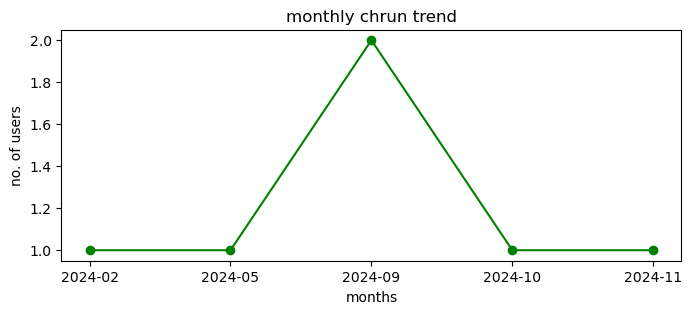

In [72]:
# monthly churn trend

df_visual['month']=df_visual['cancellation_date'].dt.to_period('M')
churn_trend=df_visual[df_visual['churn_flag']==1].groupby('month').size()

plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str),churn_trend.values,color='green',marker='o')
plt.title('monthly chrun trend')
plt.xlabel('months')
plt.ylabel('no. of users')
plt.show()

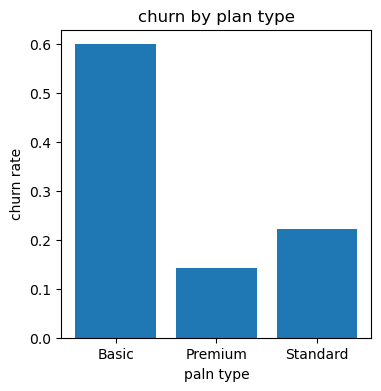

In [82]:
churn_plan=df_visual.groupby('plan_type')['churn_flag'].mean()
plt.figure(figsize=(4,4))
plt.bar(churn_plan.index,churn_plan.values)
plt.title('churn by plan type')
plt.ylabel('churn rate')
plt.xlabel('paln type')
plt.show()

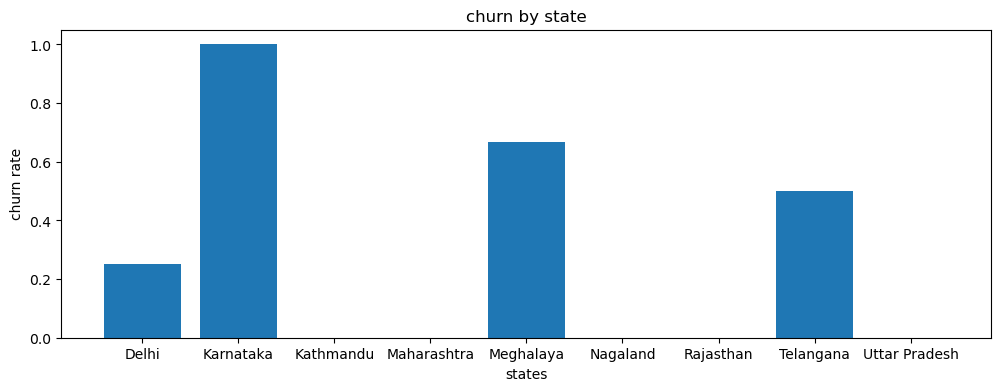

In [91]:
#churn by states
churn_state=df_visual.groupby('state')['churn_flag'].mean()
plt.figure(figsize=(12,4))
plt.tight_layout()
plt.bar(churn_state.index,churn_state.values)
plt.title('churn by state')
plt.xlabel('states')
plt.ylabel('churn rate')
plt.show()

In [109]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'complaint_date', 'escalations', 'csat_score',
       'count_complaint', 'customer_name', 'country', 'state', 'gender', 'dob',
       'pincode', 'tenure_days', 'churn_risk', 'month'],
      dtype='object')

,churn_score,churn_flag,plan_type,churn_risk,escalations,contract_type
0,12,0,Standard,low,0,Annual
1,91,1,Premium,high,1,Annual
2,34,0,Basic,low,0,Monthly
3,8,0,Premium,low,0,Annual
4,88,1,Standard,high,1,Monthly


In [111]:
# wrong
# cat_columns=['plan_type','churn_risk','contract_type']

# for columns in cat_columns:
#     df_encoded[columns]=df_encoded[columns].astype('category').cat.codes
    

In [116]:
df_encoded=df_visual[['churn_score','churn_flag','plan_type','churn_risk','escalations','contract_type']].head()
order_mapping={
    'plan_type':['Basic','Standard','Premium'],
    'churn_risk':['low','med','high'],
    'contract_type':['Monthly','Annual']
}


In [117]:
for col,order in order_mapping.items():
    df_encoded[col]=pd.Categorical(df_encoded[col].astype('category'),categories=order,ordered=True).codes

In [118]:
df_encoded.head()

,churn_score,churn_flag,plan_type,churn_risk,escalations,contract_type
0,12,0,1,0,0,1
1,91,1,2,2,1,1
2,34,0,0,0,0,0
3,8,0,2,0,0,1
4,88,1,1,2,1,0


<Axes: >

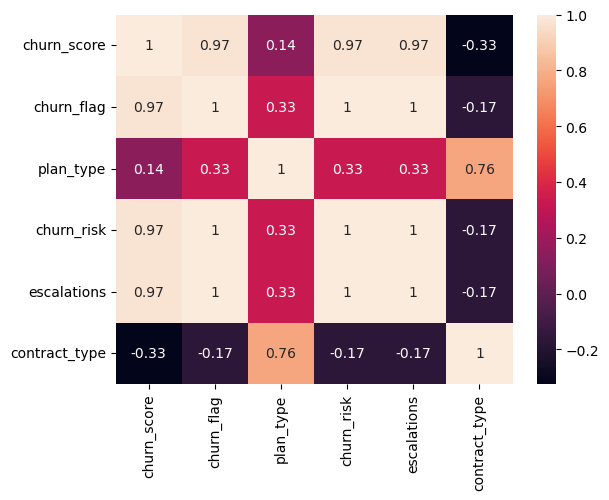

In [119]:
sns.heatmap(df_encoded.corr(),annot=True)

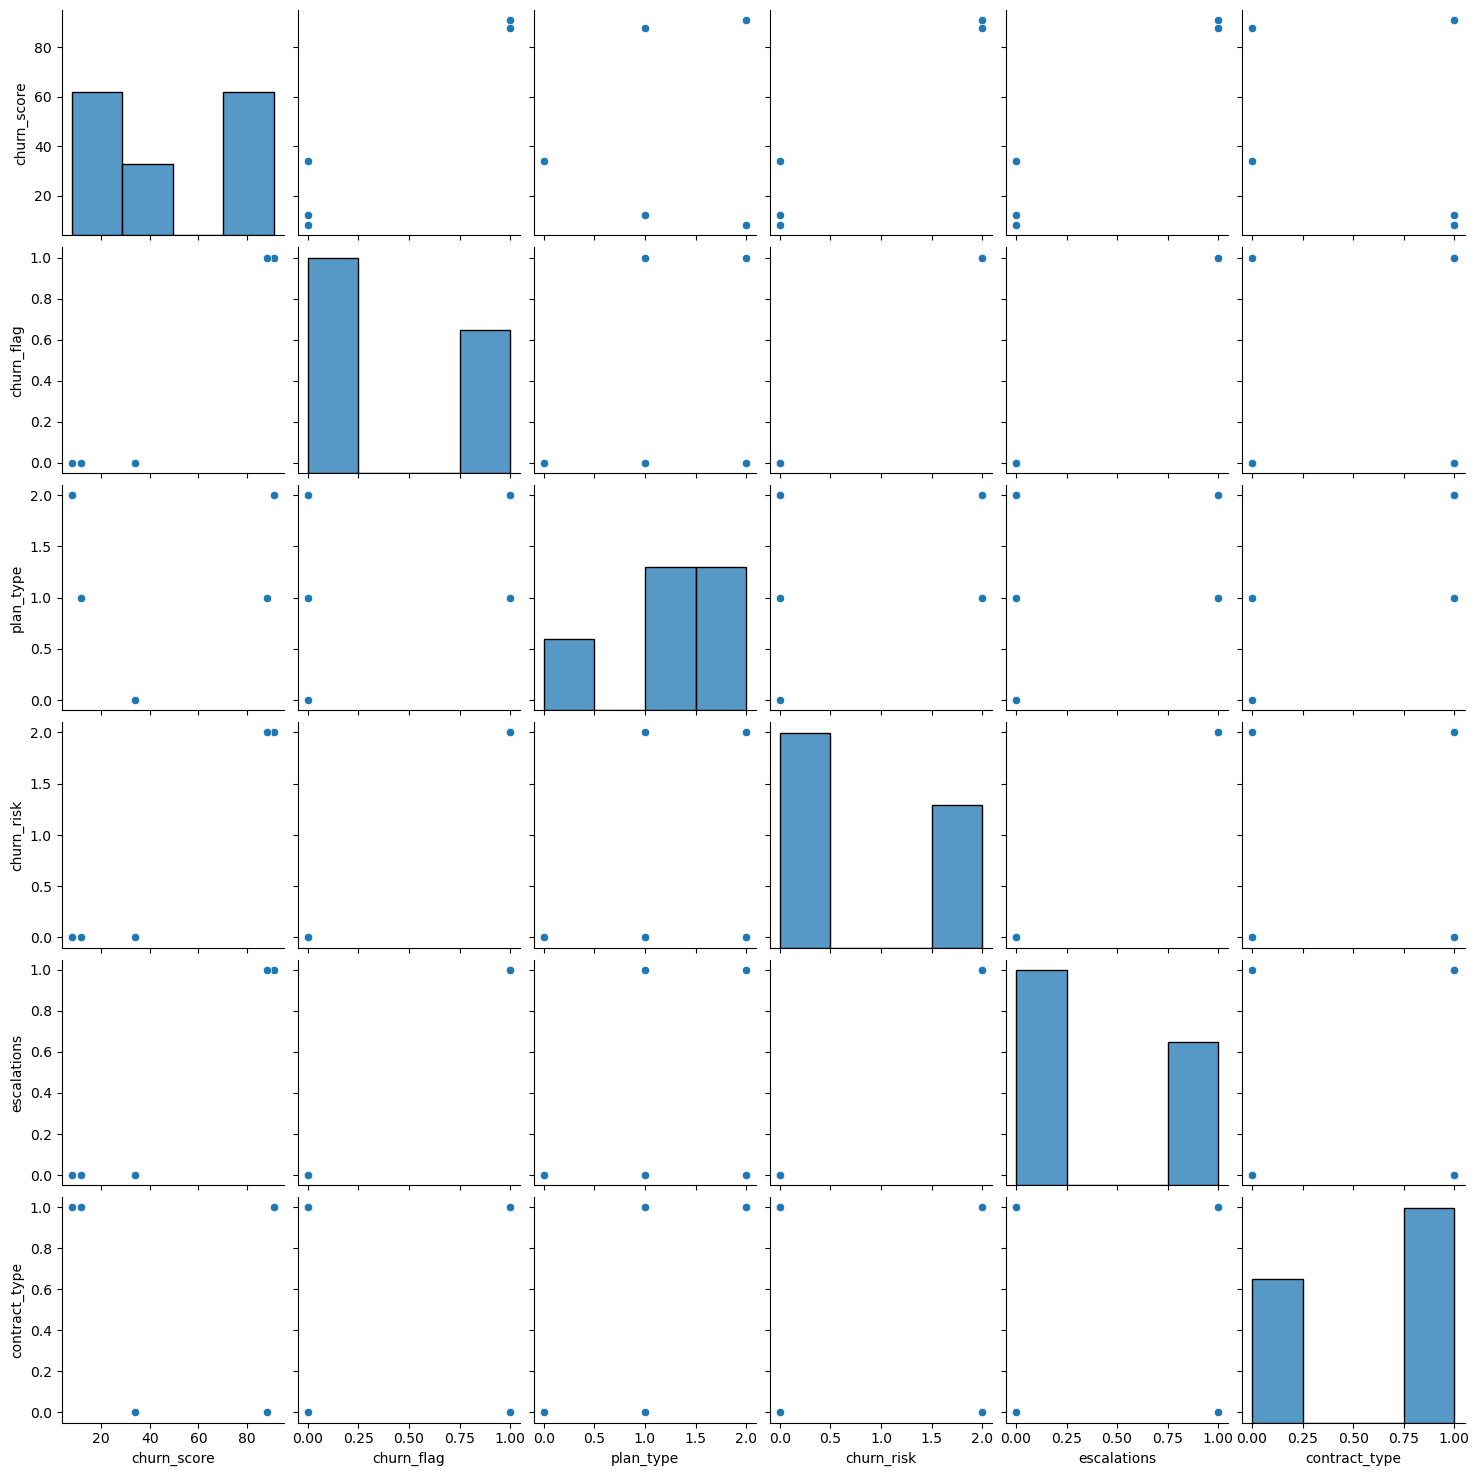

In [120]:
sns.pairplot(df_encoded)

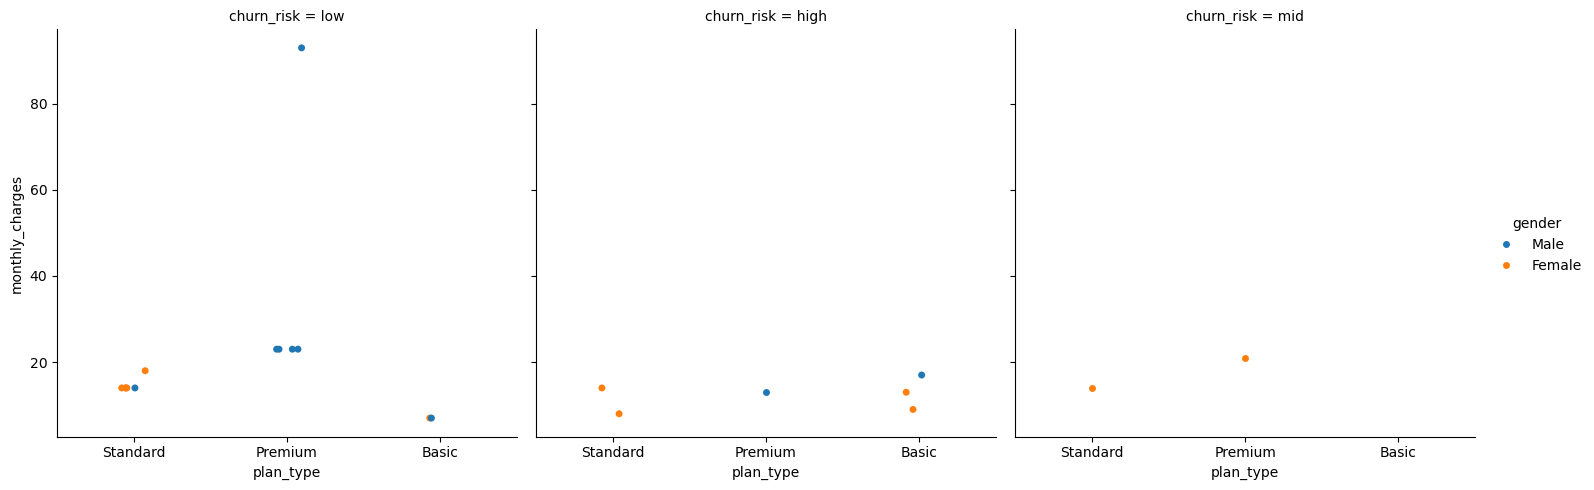

In [122]:
sns.catplot(
    data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk'
)

In [124]:
pd.pivot_table(
    df_visual,
    values='churn_flag',
    index='plan_type',
    aggfunc='mean'
)

,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222
